# 01 - Exploratory Data Analysis

Council Grove Field, Kansas (Panoma gas field / Council Grove interval).
Nine wells, wireline logs (GR, resistivity, density-neutron derived
porosity, PE) plus a hand-picked facies label per half-foot sample.
Data originates from the Kansas Geological Survey and was compiled for
Brendon Hall's 2016 SEG "facies classification using machine learning"
tutorial / contest -- I'm reusing that compilation because it's real
operator-adjacent log data with geologist-reviewed labels, which is
hard to come by publicly.

Goal for this notebook: understand what we're working with before any
modeling -- class balance, per-well behavior, and whether the curves
actually separate the facies at all (if they don't, no amount of model
complexity is going to fix that).

In [1]:
import sys
sys.path.insert(0, "..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.data_loader import load_raw, FACIES_LABELS, LOG_CURVES

pd.set_option("display.width", 120)
df = load_raw()
df.head()

,Facies,Formation,Well Name,Depth,GR,ILD_log10,DeltaPHI,PHIND,PE,NM_M,RELPOS
0,3,A1 SH,SHRIMPLIN,2793.0,77.45,0.664,9.9,11.915,4.6,1,1.000
1,3,A1 SH,SHRIMPLIN,2793.5,78.26,0.661,14.2,12.565,4.1,1,0.979
2,3,A1 SH,SHRIMPLIN,2794.0,79.05,0.658,14.8,13.050,3.6,1,0.957
3,3,A1 SH,SHRIMPLIN,2794.5,86.10,0.655,13.9,13.115,3.5,1,0.936
4,3,A1 SH,SHRIMPLIN,2795.0,74.58,0.647,13.5,13.300,3.4,1,0.915


In [2]:
print(f"{len(df)} labeled depth samples across {df['Well Name'].nunique()} wells")
df.groupby("Well Name", observed=True).agg(
    n_samples=("Depth", "size"),
    top=("Depth", "min"),
    base=("Depth", "max"),
).sort_values("n_samples", ascending=False)

3232 labeled depth samples across 8 wells


,n_samples,top,base
Well Name,,,
CROSS H CATTLE,501,2573.5,2841.5
SHRIMPLIN,471,2793.0,3028.0
NEWBY,463,2826.0,3057.0
LUKE G U,461,2610.5,2842.0
SHANKLE,449,2774.5,3008.0
NOLAN,415,2853.5,3060.5
CHURCHMAN BIBLE,404,2917.5,3122.5
Recruit F9,68,2843.0,3104.5


Recruit F9 stands out immediately -- 68 samples against several
hundred for the others. It's a real well in the dataset but it's thin
enough that I won't want to lean on it as a blind-test well later;
worth flagging now rather than discovering it during evaluation.

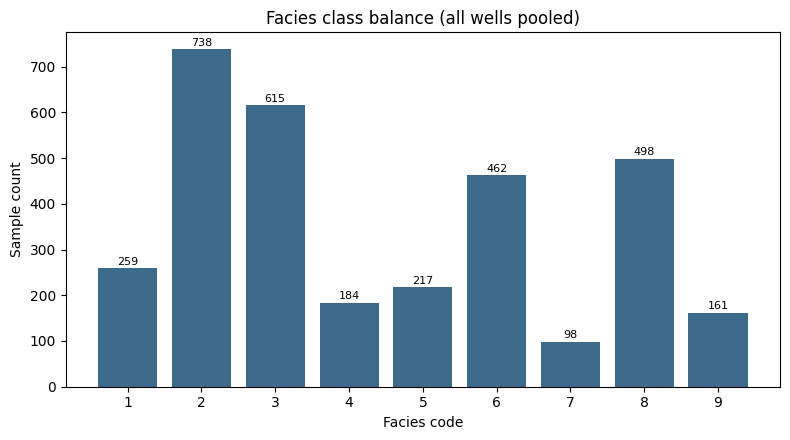

most common facies is 2 Nonmarine coarse siltstone (738 samples, 23% of the data)
rarest facies is 7 Dolomite (98 samples, 3% of the data)


In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
counts = df["Facies"].value_counts().sort_index()
labels = [f"{f}\n{FACIES_LABELS[f]}" for f in counts.index]
bars = ax.bar(counts.index.astype(str), counts.values, color="#3d6b8c")
ax.set_xlabel("Facies code")
ax.set_ylabel("Sample count")
ax.set_title("Facies class balance (all wells pooled)")
for b, c in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, c + 8, str(c), ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("../figures/facies_class_balance.png", dpi=130)
plt.show()
print("most common facies is", counts.idxmax(), FACIES_LABELS[counts.idxmax()],
      f"({counts.max()} samples, {counts.max()/len(df):.0%} of the data)")
print("rarest facies is", counts.idxmin(), FACIES_LABELS[counts.idxmin()],
      f"({counts.min()} samples, {counts.min()/len(df):.0%} of the data)")

About a 7.5x gap between the most and least common facies (facies 2,
nonmarine coarse siltstone, vs. facies 7, dolomite). This is the reason
`class_weight="balanced"` / sample weighting shows up in every model
downstream -- an unweighted classifier would just learn to guess facies
2 disproportionately often and still post a deceptively okay accuracy
number.

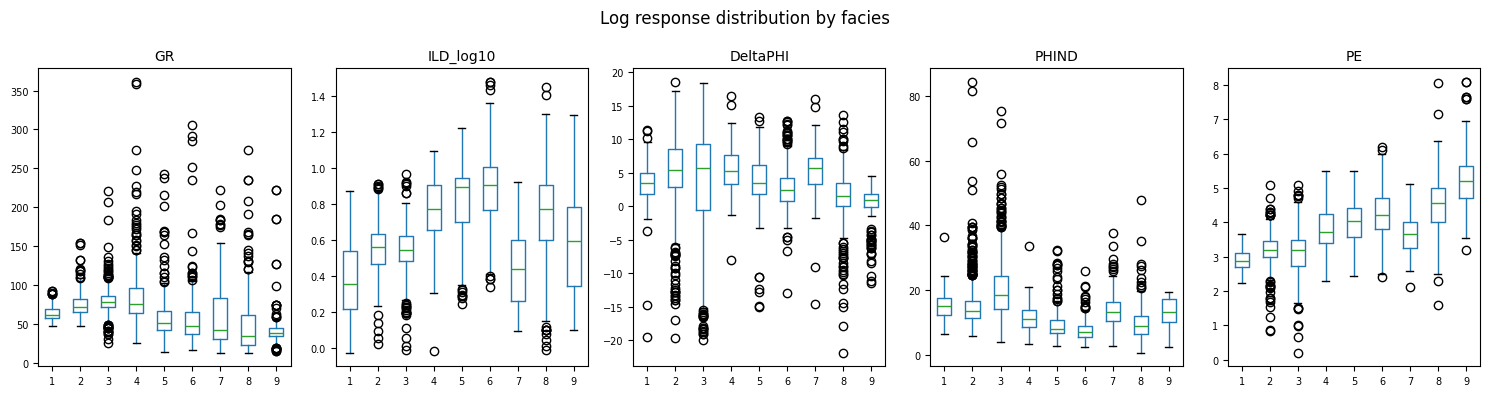

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(15, 4), sharey=False)
curves_to_plot = ["GR", "ILD_log10", "DeltaPHI", "PHIND", "PE"]
for ax, curve in zip(axes, curves_to_plot):
    df.boxplot(column=curve, by="Facies", ax=ax, grid=False, fontsize=7)
    ax.set_title(curve, fontsize=10)
    ax.set_xlabel("")
plt.suptitle("Log response distribution by facies")
plt.tight_layout()
plt.savefig("../figures/log_response_by_facies.png", dpi=130)
plt.show()

GR separates the marine shale/siltstone facies (4, 5) from the cleaner
carbonate facies (6-9) reasonably well, which matches the geology --
shale-rich intervals read high GR, clean carbonates read low. PE is
the clearest carbonate-vs-siliciclastic discriminator, as expected
(photoelectric factor is basically a matrix-lithology detector). No
single curve cleanly separates all nine classes on its own, which is
exactly why this is a multivariate classification problem instead of
a set of GR cutoffs -- worth keeping the "classical" cutoff-style
baseline modest in ambition.

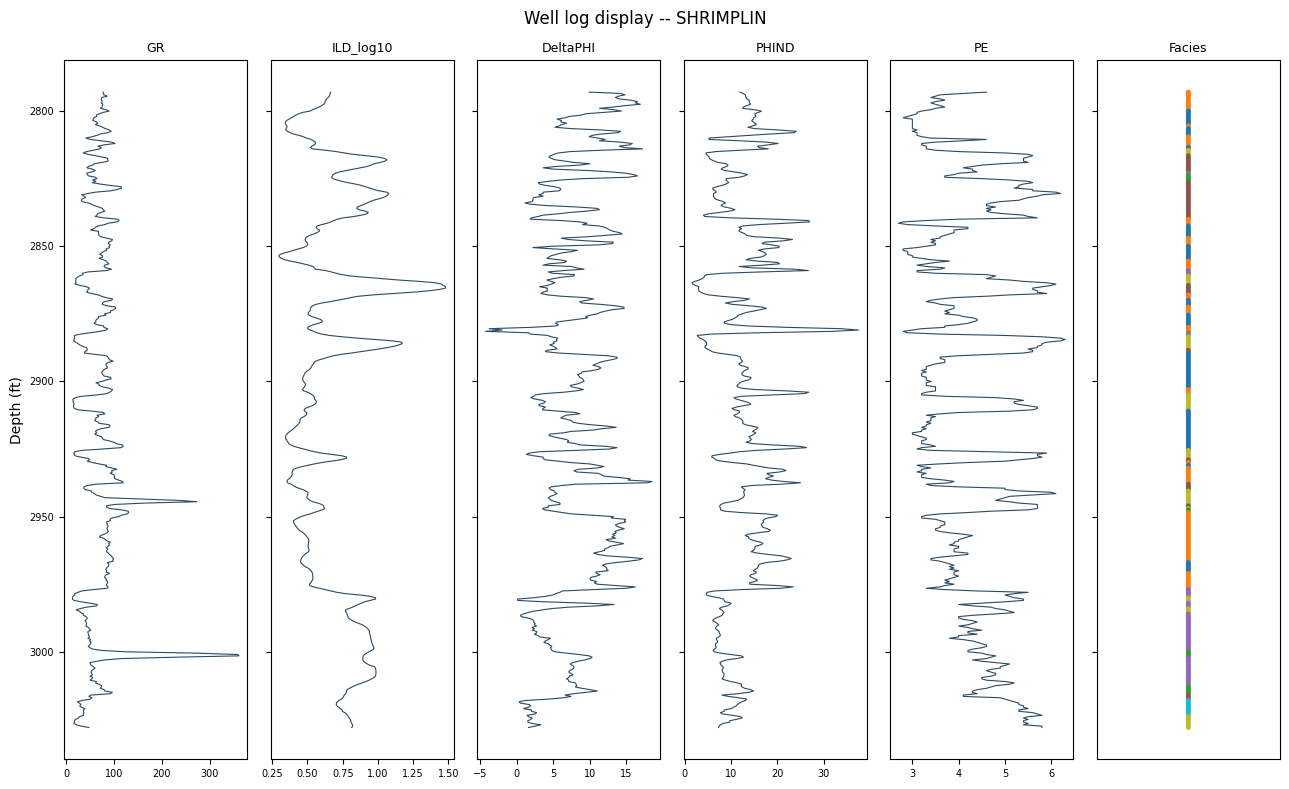

In [5]:
well = "SHRIMPLIN"
w = df[df["Well Name"] == well].sort_values("Depth")
fig, axes = plt.subplots(1, 6, figsize=(13, 8), sharey=True)
track_curves = ["GR", "ILD_log10", "DeltaPHI", "PHIND", "PE"]
for ax, curve in zip(axes, track_curves):
    ax.plot(w[curve], w["Depth"], lw=0.8, color="#2b4a63")
    ax.set_title(curve, fontsize=9)
    ax.invert_yaxis()
    ax.tick_params(labelsize=7)
axes[-1].scatter([0]*len(w), w["Depth"], c=w["Facies"], cmap="tab10", s=6)
axes[-1].set_title("Facies", fontsize=9)
axes[-1].set_xticks([])
axes[0].set_ylabel("Depth (ft)")
plt.suptitle(f"Well log display -- {well}")
plt.tight_layout()
plt.savefig("../figures/well_log_display_shrimplin.png", dpi=130)
plt.show()

This is the standard "log track" view. Two things worth noting for
modeling: facies bands are contiguous over multiple depth samples
(beds have real thickness, typically several feet), and transitions
tend to be gradual on some curves (PHIND, DeltaPHI) and sharper on
others (PE). That contiguity is exactly what a plain row-independent
classifier can't see and what the depth-window CNN is meant to pick
up on later.

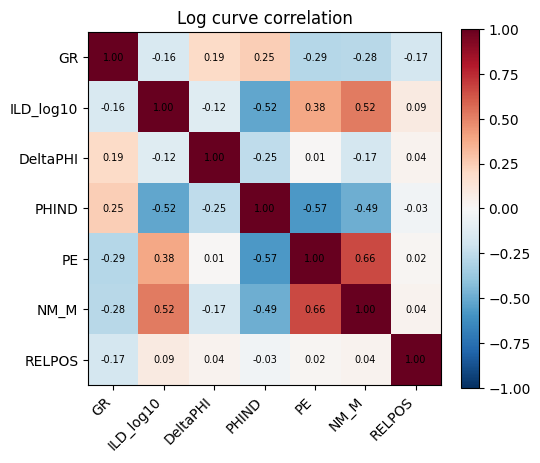

In [6]:
corr = df[LOG_CURVES].corr()
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(LOG_CURVES))); ax.set_xticklabels(LOG_CURVES, rotation=45, ha="right")
ax.set_yticks(range(len(LOG_CURVES))); ax.set_yticklabels(LOG_CURVES)
for i in range(len(LOG_CURVES)):
    for j in range(len(LOG_CURVES)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(im, fraction=0.046)
plt.title("Log curve correlation")
plt.tight_layout()
plt.savefig("../figures/log_curve_correlation.png", dpi=130)
plt.show()

DeltaPHI and PHIND are correlated (both porosity-derived, expected).
Nothing extreme enough to drop a curve outright, but it's a reminder
that the effective dimensionality here is lower than 7 raw curves --
tree-based models won't care much, but it's part of why LDA (which
handles correlated predictors less gracefully) doesn't automatically
lose to the tree models later.

Next: `02_feature_engineering.ipynb` -- per-well normalization and the
depth-window features used by the tabular and sequence models.